# 🧠 Training Your First Ensemble Model

## 🎯 Objective

In this assignment, you’ll evaluate the **ensemble model** you trained in **Module 5** (Random Forest or XGBoost) using appropriate **classification metrics**.

Your goal is to understand:
- What these numbers mean
- Where they fall short
- How they reflect the model’s usefulness

This is **not just about getting high scores**, but about **interpreting** what those scores reveal.

---

## 🧩 Assignment Instructions

### 📁 Load Your Previous Dataset

- Load your `additional_files/customer_churn_gold.csv` dataset
- Check for nulls, data types, and shapes  
- Split into features (`X`) and target (`y = Churn`)
- Store your results in variable `X` and `y`
---

In [1]:
import pandas as pd
import numpy as np 

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

#### This dataset is already processed in module 3 assignment and is being used here ####

In [3]:
# YOUR CODE HERE
df = pd.read_csv('additional_files/customer_churn_gold.csv')
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,Churn_encoded,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,...,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.0,0.083333,0,0.0
1,1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,...,56.95,1889.50,-0.172165,0.066327,-0.259629,0.0,1.0,2.833333,1,0.0
2,2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,...,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,1.0,0.166667,0,0.0
3,3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,...,42.30,1840.75,-0.193672,0.514251,-0.746535,0.0,2.0,3.750000,1,0.0
4,4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,...,70.70,151.65,-0.938874,-1.236724,0.197365,1.0,0.0,0.166667,0,0.0


In [4]:
df = df[df.columns[1:]]

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,Churn_encoded,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.0,0.083333,0,0.0
1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,56.95,1889.50,-0.172165,0.066327,-0.259629,0.0,1.0,2.833333,1,0.0
2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,1.0,0.166667,0,0.0
3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,42.30,1840.75,-0.193672,0.514251,-0.746535,0.0,2.0,3.750000,1,0.0
4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,70.70,151.65,-0.938874,-1.236724,0.197365,1.0,0.0,0.166667,0,0.0


In [17]:
X = df[[col for col in df.columns if col != 'Churn_encoded'] ]
y = df['Churn_encoded'].astype('int')

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X`, `y` respectively.
 -  If these variable are not found, you answer will be rejected by the system

## 📂 Loading your data

- Clean and transform your data.
    - Drop the `customerID` column
    - Convert `TotalCharges` to numeric (handles spaces or non-numeric values)
    - Convert target column `y` to binary values
    - Identify column types
    - Convert relevant columns using one hot encoding and fill in any missing values using `SimpleImputer`

Store your clean data into a variable named `X_cleaned`.
Your X_cleaned should be a numpy array that looks like this 

```python
([[  0.  ,   1.  ,  29.85, ...,   0.  ,   1.  ,   0.  ],
       [  0.  ,  34.  ,  56.95, ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,   2.  ,  53.85, ...,   0.  ,   0.  ,   1.  ],
```

Hint :- Your `X_cleaned `should have an approximate shape of (7043, 45)

Overall, 
- Recreate the **features** and **target** used in your ensemble model from your `X` & `y`

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [18]:
# YOUR CODE HERE
X.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,1.0,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.083333,0,0.0
1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,0.0,56.95,1889.50,-0.172165,0.066327,-0.259629,1.0,2.833333,1,0.0
2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,1.0,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,0.166667,0,0.0
3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,0.0,42.30,1840.75,-0.193672,0.514251,-0.746535,2.0,3.750000,1,0.0
4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,1.0,70.70,151.65,-0.938874,-1.236724,0.197365,0.0,0.166667,0,0.0


In [19]:
X_cleaned = X.drop('customerID', axis = 1)

In [20]:
X_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,2.0,...,1.0,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.083333,0,0.0
1,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,0.0,...,0.0,56.95,1889.50,-0.172165,0.066327,-0.259629,1.0,2.833333,1,0.0
2,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,2.0,...,1.0,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,0.166667,0,0.0
3,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,0.0,...,0.0,42.30,1840.75,-0.193672,0.514251,-0.746535,2.0,3.750000,1,0.0
4,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,0.0,...,1.0,70.70,151.65,-0.938874,-1.236724,0.197365,0.0,0.166667,0,0.0


In [21]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn_encoded, dtype: int64

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X_cleaned` respectively.
 -  If these variable are not found, you answer will be rejected by the system

## 📂 Splitting your data
Now that we have cleaned our data. 
- Time to split our data into train and test sets,
- Go for a 75/25 split or anything near that. 
- Store your answer in the variable named `X_train`, `X_test`, `y_train`, `y_test` respectively

In [22]:
from sklearn.model_selection import train_test_split

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size = 0.25, stratify = y)

In [24]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
1967,1.0,0,0.0,0.0,69,1.0,2.0,0.0,2.0,2.0,...,1.0,78.60,5356.45,1.357394,1.491540,0.459929,3.0,5.750000,1,2.0
1623,0.0,0,0.0,0.0,54,1.0,2.0,1.0,0.0,2.0,...,1.0,97.20,5129.45,1.257246,0.880735,1.078118,2.0,4.500000,1,4.0
3854,0.0,0,1.0,0.0,50,1.0,2.0,1.0,2.0,2.0,...,1.0,109.65,5405.80,1.379167,0.717853,1.491905,2.0,4.166667,1,4.0
4865,0.0,0,1.0,1.0,7,1.0,2.0,0.0,0.0,0.0,...,0.0,48.80,349.80,-0.851454,-1.033122,-0.530502,0.0,0.583333,0,0.0
2563,1.0,1,0.0,0.0,25,1.0,2.0,1.0,0.0,2.0,...,0.0,105.95,2655.25,0.165671,-0.300156,1.368932,1.0,2.083333,1,4.0


In [27]:
y_train.value_counts() / y_train.sum()

Churn_encoded
0    2.767475
1    1.000000
Name: count, dtype: float64

In [28]:
y_test.value_counts() /y_test.sum()

Churn_encoded
0    2.770878
1    1.000000
Name: count, dtype: float64

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X_train`, `X_test`, `y_train`, `y_test` respectively.
 -  If these variable are not found, you answer will be rejected by the system

### 📁 Load Your Previous Model

- Now that we have our `X_train`, `X_test`, `y_train` & `y_test`. We can start training our models
- Reload or retrain the same **model** from Module 5(Random Forest or XGBoost) with your training data.
- Pick any model(Random Forest or XGBoost) and store your model in a variable named `model`
---

In [30]:
pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 2.3 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [32]:
# YOUR CODE HERE
model = RandomForestClassifier(max_depth = 8)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8)

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `model` respectively.
 -  If these variable are not found, you answer will be rejected by the system

# **✏️ Write:**
- 1 sentence confirming the model and data are loaded correctly

## Make sure to write the answer below this cell

- The model and data are loaded correctly. 

# 🔮 Generate Predictions

- Use `.predict()` to generate predictions on your **test set**
- Store your predictions for the training data in a variable named `train_preds`
- Store your predictions for the testing data in a variable named `test_preds`
---

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [33]:
# YOUR CODE HERE
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `train_preds` & `test_preds` respectively.
 -  If these variable are not found, you answer will be rejected by the system

### 🧮 Calculate These Metrics

Calculate the following **classification metrics**:

| **Metric**  | **What it Measures**                                           |
|-------------|----------------------------------------------------------------|
| Accuracy    | Overall % of predictions that were correct                     |
| Precision   | Among predicted churns, how many were actually churned?        |
| Recall      | Among actual churns, how many did the model identify?          |
| F1 Score    | Harmonic mean of precision and recall                          |


Do so for both the `training` and `test` set. 
- Store your results in variables named `train_acc` & `test_acc` for `accuracy_score`.
- Store your results in variables named `train_precision` & `test_precision` for `precision_score`.
- Store your results in variables named `train_recall` & `test_recall` for `recall_score`.
- Store your results in variables named `train_f1` & `test_f1` for `f1_score`.

---

In [34]:
# Accuracy
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [36]:
# YOUR CODE HERE
train_acc = accuracy_score(train_preds, y_train)
test_acc = accuracy_score(test_preds, y_test)

print(train_acc, test_acc)

0.8513820522529345 0.8040885860306644


In [37]:
train_precision = precision_score(y_train, train_preds)
test_precision = precision_score(y_test, test_preds)

print(train_precision, test_precision)

0.7986447241045499 0.6694444444444444


In [39]:
train_recall = recall_score(y_train, train_preds)
test_recall = recall_score(y_test, test_preds)

print(train_recall, test_recall)

0.5884450784593438 0.5160599571734475


In [41]:
train_f1 = f1_score(y_train, train_preds)
test_f1 = f1_score(y_test, test_preds)

print(train_f1, test_f1)

0.6776180698151951 0.5828295042321644


In [42]:
print("Accuracy of train and test: ", train_acc, test_acc)
print("Precision of train and test: ", train_precision, test_precision)
print("Recall of train and test: ", train_recall, test_recall)
print("F1 Score of train and test: ", train_f1, test_f1)

Accuracy of train and test:  0.8513820522529345 0.8040885860306644
Precision of train and test:  0.7986447241045499 0.6694444444444444
Recall of train and test:  0.5884450784593438 0.5160599571734475
F1 Score of train and test:  0.6776180698151951 0.5828295042321644


---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named 
    - `train_acc` & `test_acc`
    - `train_precision` & `test_precision`
    - `train_recall` & `test_recall`
    - `train_f1` & `test_f1` 
 -  If these variable are not found, you answer will be rejected by the system

### 🧠 Interpret the Results

For **each metric** you calculated:

**✏️ Write (1–2 sentences per metric):**
- What does this metric tell you in the context of **customer churn**?
- Is the score **good enough** for a business use-case? Why or why not?
- Are there any **trade-offs** shown between precision and recall?
- What does the **confusion matrix** reveal about where your model succeeds or struggles?

---

## Make sure to write the answer below this cell

- The customer churn model has decent accuracy and precision. But the recall is close to 50% or test data. This tells us that the model is unable to detect 50% of churned customers.
- No, the score is not good enough. Recall is the most costliest metric in this business usecase. As it is just 50%, it is not reliable enough.
- Yes. Precision and recall measure exactly the opposite metrics: false positives and false negatives respectively.
- The confusion metrics gives a granular view on how many of the predictions are false in predicting churn or no churn. Helping us understand what might be going wrong.

### 📉 Visualize the Confusion Matrix

Use a **visualization** to display the confusion matrix:

```python
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
```
---

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

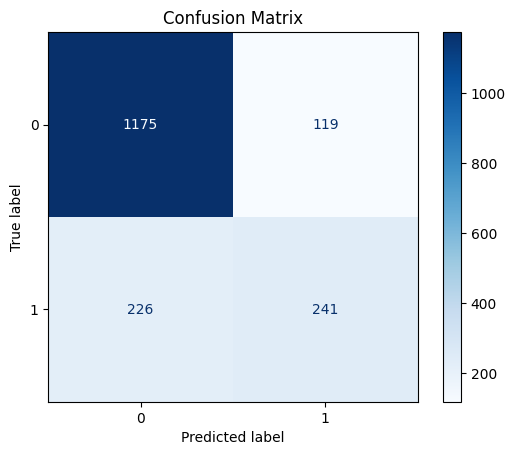

In [44]:
# YOUR CODE HERE
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

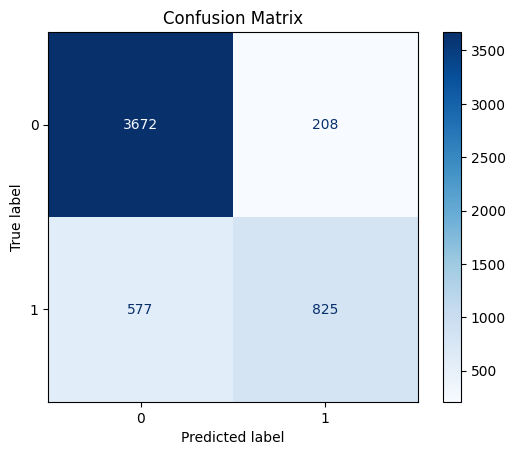

In [45]:
ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    

# **✏️ Write (2–4 sentences):**

- What kind of **mistakes** is your model making?
- Which type of **error** (false positives or false negatives) might be more **costly for the business**, and why?

## Make sure to write the answer below this cell

- The model is generalizing no churn. As the labels have a slight imbalance, it is biased towards no-churn. 
- False negatives are more costly for the business. It means that the model is unable to predict the customer who is about to leave, which is really costly for the business. 

### 💡 Recommendation

# **✏️ Write:**

- If you were presenting this to a **non-technical stakeholder**, which **one metric** would you highlight and **why**?

---

## Make sure to write the answer below this cell

- I would highlight the recall of the model. Which means that I am emphasizing on predicting whether a customer will leave. 

# 📝 Summary

**✏️ Write (2–3 sentences):**

- Is this a **useful model** for predicting churn?
- What would be your **next step** to improve it?

---

## Make sure to write the answer below this cell

- This model cannot be completely trusted due to a 0.5 recall score. 
- I can tune the hyperparameters, lower the classification

## ✅ Deliverables Checklist

- [ ] Model loaded and test predictions generated  
- [ ] All four metrics (`accuracy`, `precision`, `recall`, `f1`) calculated  
- [ ] Each metric clearly interpreted  
- [ ] Confusion matrix (visual or table) included and described  
- [ ] Recommendation with regards to business relevance  
- [ ] Summary about model usefulness and next steps


---

<h2><center> Completing your test </center></h2>

- Once you have completed your test and answered all the questions:
  
- You can open the guide using the button located on the far right of your screen.

- The button will look like this image:  
  ![](additional_files/End_guide_button.png)

- Clicking on this button will allow you to mark the test as complete using the button shown below:  
  ![](additional_files/completion_button.png)

- Please click on **Mark as Completed** to end and submit your test.

- Thank you!
